In [1]:
import sys
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "src" / "config.py").exists():
    repo_root = repo_root.parent
if not (repo_root / "src" / "config.py").exists():
    raise FileNotFoundError(f"Couldn't find src/config.py from {Path.cwd()}")

sys.path.insert(0, str(repo_root))

from src.config import CONFIG
from src.dataset.utils.spectrograms import build_spectrogram_dataset_v1
from pathlib import Path
import pandas as pd


In [2]:
idx_path = build_spectrogram_dataset_v1(
    non_bird_cap=1000,
    seed=22,
    save_full=True,
    overwrite=False,
)

print("Wrote index:", idx_path)


Generating spectrograms: 100%|██████████| 18435/18435 [00:45<00:00, 405.39it/s]


Wrote index: bird_data/spectrograms_v1/index_train_64x128.csv


class_name
non_bird                      1000
aegithalos_caudatus            504
carduelis_carduelis            490
prunella_modularis             488
saxicola_rubicola              469
hirundo_rustica                459
troglodytes_troglodytes        458
pica_pica                      440
corvus_corax                   437
periparus_ater                 437
streptopelia_decaocto          431
phylloscopus_collybita         430
columba_palumbus               420
apus_apus                      418
spinus_spinus                  409
cuculus_canorus                406
acrocephalus_schoenobaenus     405
chloris_chloris                403
cyanistes_caeruleus            402
falco_tinnunculus              401
passer_domesticus              397
garrulus_glandarius            393
parus_major                    387
erithacus_rubecula             386
dendrocopos_major              377
corvus_frugilegus              377
buteo_buteo                    372
fringilla_coelebs              367
phyllosco

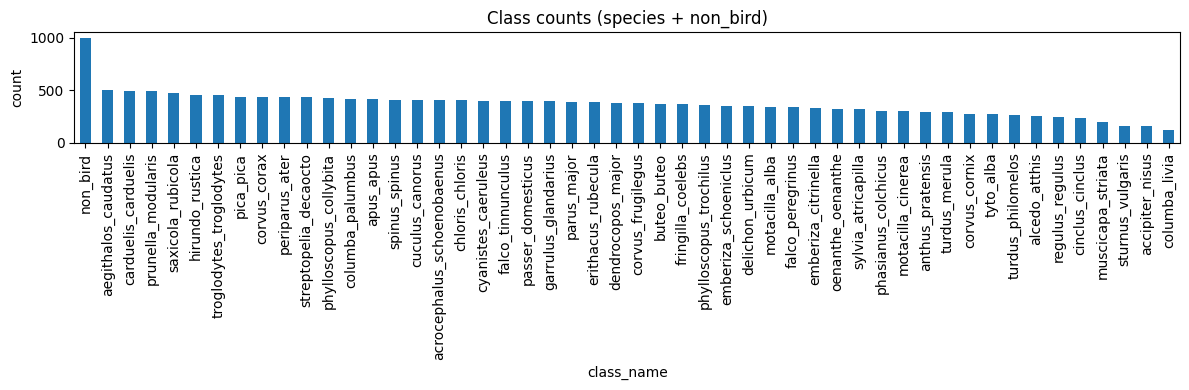

In [3]:
# --- Class count bar chart from train index ---
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Update this if your output folder/name differs
index_csv = Path('bird_data/spectrograms_v1/index_train_64x128.csv')
if not index_csv.exists():
    raise FileNotFoundError(f'Index CSV not found: {index_csv.resolve()}')

df = pd.read_csv(index_csv)
if 'class_name' not in df.columns:
    raise ValueError('Expected a class_name column in the index CSV')

counts = df['class_name'].value_counts().sort_values(ascending=False)
print(counts)

plt.figure(figsize=(12, 4))
counts.plot(kind='bar')
plt.title('Class counts (species + non_bird)')
plt.ylabel('count')
plt.tight_layout()
plt.show()


In [4]:
from src.dataset.utils.splits import build_default_splits_for_spectrograms_v1

paths = build_default_splits_for_spectrograms_v1()
paths


{'train': PosixPath('bird_data/spectrograms_v1/splits/train.csv'),
 'val': PosixPath('bird_data/spectrograms_v1/splits/val.csv'),
 'test': PosixPath('bird_data/spectrograms_v1/splits/test.csv'),
 'classes': PosixPath('bird_data/spectrograms_v1/splits/classes.json'),
 'info': PosixPath('bird_data/spectrograms_v1/splits/split_info.json')}